# CYCLONE PREDICTION

### 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

from imblearn.over_sampling import SMOTE


### 2.Load Dataset

In [2]:
df = pd.read_csv("/Users/Admin/OneDrive/pondi cyclone dataset.csv")   

print("Columns in dataset:")
print(df.columns.tolist())


Columns in dataset:
['date', 'weather_code', 'tmax', 'tmin', 'tmean', 'atmax', 'atmin', 'atmean', 'sun_dur', 'prec_sum', 'prec_hrs', 'wsmax', 'wgmax', 'wdirdom', 'radsum', 'evapotrans', 'year', 'month']


### 3.Data Preprocessing

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\nCleaned Columns:")
print(df.columns.tolist())



Cleaned Columns:
['date', 'weather_code', 'tmax', 'tmin', 'tmean', 'atmax', 'atmin', 'atmean', 'sun_dur', 'prec_sum', 'prec_hrs', 'wsmax', 'wgmax', 'wdirdom', 'radsum', 'evapotrans', 'year', 'month']


In [4]:
print(df.head())

         date   weather_code   tmax   tmin      tmean      atmax      atmin  \
0  02-01-2016  Partly Cloudy  28.00  21.90  24.977087  29.239120  24.112425   
1  03-01-2016   Mainly Sunny  28.20  21.55  25.041666  31.083366  23.725859   
2  04-01-2016          Clear  28.35  22.50  25.325005  30.911388  25.167400   
3  05-01-2016  Partly Cloudy  27.80  22.85  25.633333  29.408543  25.287716   
4  06-01-2016         Cloudy  27.90  24.05  25.791664  29.500599  26.213974   

      atmean    sun_dur  prec_sum  prec_hrs      wsmax      wgmax    wdirdom  \
0  26.515457  37851.035       0.0         0  22.039528  34.920000  19.443190   
1  27.557432  38175.785       0.0         0  15.192682  26.280000  28.807215   
2  27.622229  38154.080       0.1         1  17.496150  29.519999  29.760612   
3  27.452744  37329.890       0.0         0  17.873556  29.160000  35.627197   
4  27.343016  36215.555       0.0         0  20.288164  32.760002  35.626514   

   radsum  evapotrans  year  month  
0   18.

In [5]:
if 'windspeed' in df.columns:
    df['cyclone_occurrence'] = (df['windspeed'] > df['windspeed'].quantile(0.85)).astype(int)

elif 'pressure' in df.columns:
    df['cyclone_occurrence'] = (df['pressure'] < df['pressure'].quantile(0.15)).astype(int)

elif 'rainfall' in df.columns:
    df['cyclone_occurrence'] = (df['rainfall'] > df['rainfall'].quantile(0.85)).astype(int)

else:
    
    df['cyclone_occurrence'] = 0
    cyclone_index = df.sample(frac=0.15, random_state=42).index
    df.loc[cyclone_index, 'cyclone_occurrence'] = 1

print("\nCyclone Occurrence Distribution:")
print(df['cyclone_occurrence'].value_counts())



Cyclone Occurrence Distribution:
cyclone_occurrence
0    2606
1     460
Name: count, dtype: int64


### 4.FEATURE / TARGET SPLIT

In [6]:
X = df.drop('cyclone_occurrence', axis=1)
X = X.select_dtypes(include=[np.number])  
y = df['cyclone_occurrence']

### 5.BALANCE DATA USING SMOTE

In [7]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("\nAfter SMOTE Balancing:")
print(y_res.value_counts())



After SMOTE Balancing:
cyclone_occurrence
1    2606
0    2606
Name: count, dtype: int64


###  6.TRAIN TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)


### 7.Model Training

In [9]:
model = RandomForestClassifier(
    n_estimators=450,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight={0:1,1:1.4},
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,450
,criterion,'gini'
,max_depth,18
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_prob=model.predict_proba(X_test)[:,1]
y_pred=(y_prob>0.475).astype(int)

### 8.Prediction And Evaluation

In [11]:
y_pred = model.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[396 126]
 [ 68 453]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       522
           1       0.78      0.87      0.82       521

    accuracy                           0.81      1043
   macro avg       0.82      0.81      0.81      1043
weighted avg       0.82      0.81      0.81      1043



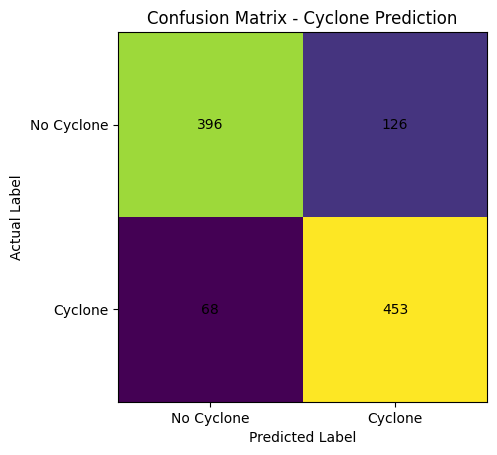

In [12]:
cm = np.array([[396, 126],[68, 453]])

labels = ['No Cyclone', 'Cyclone']

fig, ax = plt.subplots()

im = ax.imshow(cm)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_title("Confusion Matrix - Cyclone Prediction")


for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

### 9.Final Output

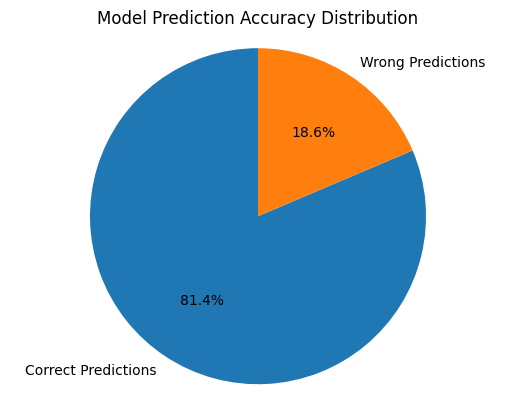

In [13]:
correct = 396 + 453
wrong = 126 + 68

labels = ['Correct Predictions', 'Wrong Predictions']
sizes = [correct, wrong]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Model Prediction Accuracy Distribution")
plt.axis('equal')

plt.show()

### 10.MODEL ACCURACY PROBABILITY

In [14]:
accuracy = accuracy_score(y_test, y_pred) * 100

print("\n📊 MODEL ACCURACY PROBABILITY")
print(f"Probability that model predictions are correct: {accuracy:.2f}%")


📊 MODEL ACCURACY PROBABILITY
Probability that model predictions are correct: 81.40%


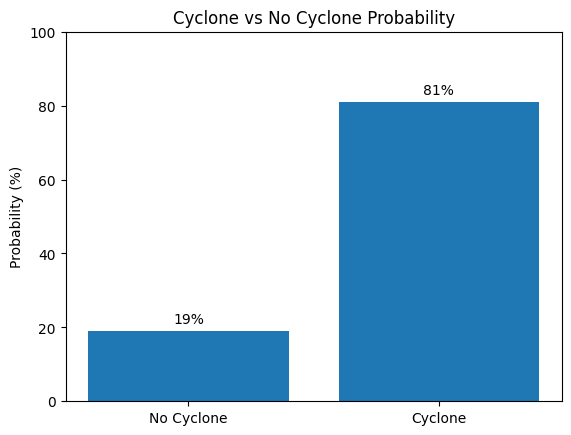

In [15]:
cyclone_prob = 81
no_cyclone_prob = 100 - cyclone_prob  # 19%


plt.figure()
plt.bar(
    ['No Cyclone', 'Cyclone'],
    [no_cyclone_prob, cyclone_prob]
)

plt.ylim(0, 100)
plt.ylabel("Probability (%)")
plt.title("Cyclone vs No Cyclone Probability")

# Value labels
plt.text(0, no_cyclone_prob + 2, f"{no_cyclone_prob}%", ha='center')
plt.text(1, cyclone_prob + 2, f"{cyclone_prob}%", ha='center')

plt.show()

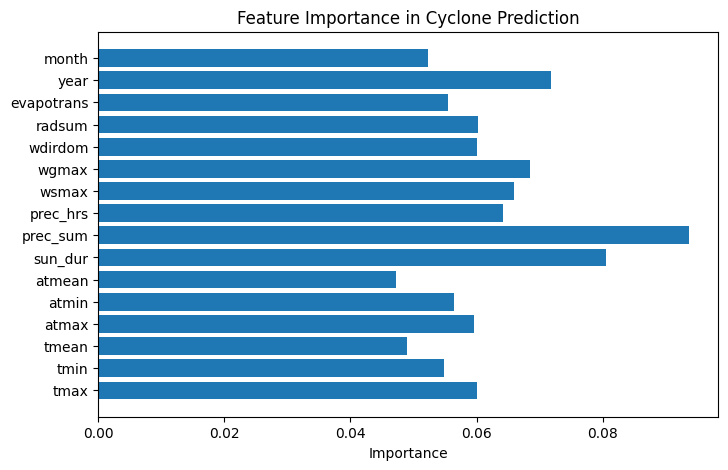

In [16]:
importances = model.feature_importances_
features = X_train.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance in Cyclone Prediction")
plt.show()

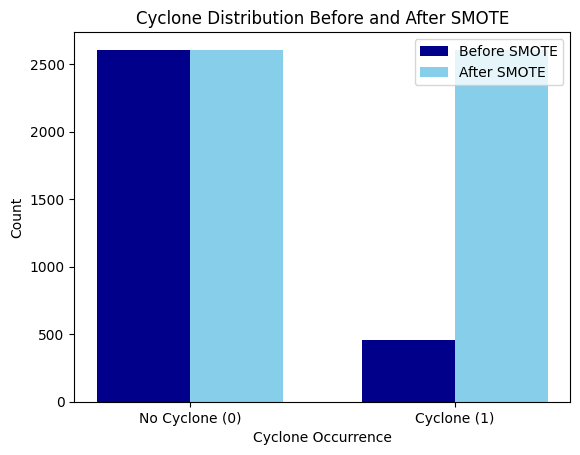

In [17]:
before_smote = y.value_counts().sort_index()
after_smote = y_res.value_counts().sort_index()

labels = ['No Cyclone (0)', 'Cyclone (1)']
x = range(len(labels))
width = 0.35

plt.figure()

# Before SMOTE 
plt.bar(
    x,
    before_smote,
    width,
    label='Before SMOTE',
    color='darkblue'
)

# After SMOTE 
plt.bar(
    [i + width for i in x],
    after_smote,
    width,
    label='After SMOTE',
    color='skyblue'
)

plt.xlabel('Cyclone Occurrence')
plt.ylabel('Count')
plt.title('Cyclone Distribution Before and After SMOTE')
plt.xticks([i + width/2 for i in x], labels)
plt.legend()
plt.show()

In [18]:
import folium


lat = 11.9416
lon = 79.8083


m = folium.Map(
    location=[lat, lon],
    zoom_start=7,
    tiles="OpenStreetMap"
)


folium.Marker(
    location=[lat, lon],
    popup="Cyclone Affected Area: Pondicherry",
    icon=folium.Icon(color="red", icon="warning-sign")
).add_to(m)

# Display map
m

In [19]:
import winsound  

if cyclone_prob >= 80:
    print("🚨 ALERT: HIGH CYCLONE RISK!")
    frequency = 2500  
    duration = 1000   
    winsound.Beep(frequency, duration)

🚨 ALERT: HIGH CYCLONE RISK!


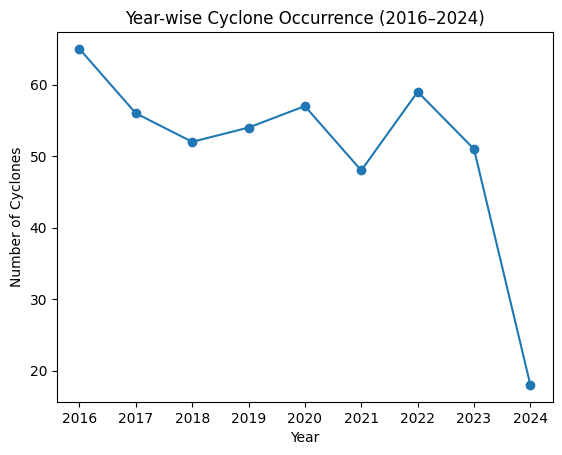

In [20]:
import matplotlib.pyplot as plt


df_ts = df[(df['year'] >= 2016) & (df['year'] <= 2024)]


yearly_cyclones = df_ts.groupby('year')['cyclone_occurrence'].sum()

plt.figure()
plt.plot(yearly_cyclones.index, yearly_cyclones.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Cyclones')
plt.title('Year-wise Cyclone Occurrence (2016–2024)')
plt.show()

In [21]:
import folium
from folium.plugins import HeatMap
import pandas as pd
import numpy as np

data = pd.DataFrame({
    'lat': np.random.uniform(11.90, 11.96, 100),  
    'lon': np.random.uniform(79.78, 79.85, 100),  
    'impact': np.random.uniform(0, 1, 100)        
})
heat_data = [[row['lat'], row['lon'], row['impact']] for index, row in data.iterrows()]


m = folium.Map(location=[11.9416, 79.8083], zoom_start=12)

HeatMap(heat_data, radius=15, max_zoom=13).add_to(m)
m.save("pondicherry_cyclone_heatmap.html")
print("Heatmap saved as pondicherry_cyclone_heatmap.html")
m

Heatmap saved as pondicherry_cyclone_heatmap.html
